In [8]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import json

# import all json files
with open("eval_results/evaluation_metrics_bert.json", "r") as f:
    bert_metrics = json.load(f)

with open("eval_results/evaluation_metrics_dictionary.json", "r") as f:
    dictionary_metrics = json.load(f)

with open("eval_results/evaluation_metrics_bert_nli.json", "r") as f:
    nli_metrics = json.load(f)

with open("eval_results/evaluation_metrics_gpt.json", "r") as f:
    gpt_metrics = json.load(f)

# combine all models
all_metrics = {**bert_metrics, **dictionary_metrics, **nli_metrics, **gpt_metrics}

# adapt the dictionary baseline
all_metrics["dictionary_baseline"] = {
    "negative_f1": all_metrics["dictionary_baseline"]["negative"]["neg"],
    "neutral_f1": all_metrics["dictionary_baseline"]["neutral"]["neutral"],
    "positive_f1": all_metrics["dictionary_baseline"]["positive"]["pos"],
    "macro_f1": (
        all_metrics["dictionary_baseline"]["negative"]["neg"]+
        all_metrics["dictionary_baseline"]["neutral"]["neutral"]+
        all_metrics["dictionary_baseline"]["positive"]["pos"]
    )/3,
    }

# reorder the dictionary
all_metrics = dict(
    (k, all_metrics[k]) for k in [
        'NLI_deberta',
        'microsoft/deberta-v3-base',
        'roberta-base',
        'bert-base-cased',
        'distilbert-base-cased',
        'dictionary_baseline',
        'gpt-4o-mini',
        'gpt-5-nano'
    ]
)

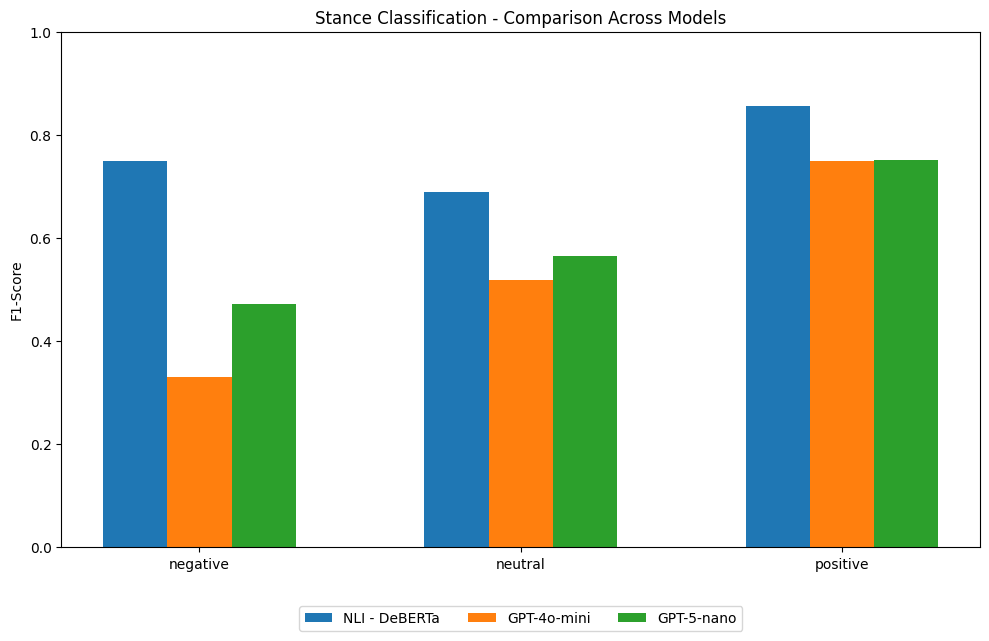

In [11]:
models = ['NLI_deberta', 'gpt-4o-mini', 'gpt-5-nano']
metrics = ['negative_f1', 'neutral_f1', 'positive_f1']
values = np.array([[all_metrics[m][metric] for metric in metrics] for m in models])
model_labels = ["NLI - DeBERTa", "GPT-4o-mini", "GPT-5-nano"]

# create the plot
x = np.arange(len(metrics))
width = 0.2
fig, ax = plt.subplots(figsize=(10, 6.5))
for i, model in enumerate(models):
    ax.bar(x + i*width, values[i], width, label=model_labels[i])
ax.set_xticks(x + width*(len(models)-1)/2)
ax.set_xticklabels(["negative", "neutral", "positive"])
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)
ax.set_title('Stance Classification - Comparison Across Models')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(models))
plt.tight_layout()
plt.show()